In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("onlinefraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
df.shape

(1048575, 11)

In [6]:
df.type.value_counts()

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

In [7]:
type=df['type'].value_counts()

In [8]:
transactions=type.index

In [9]:
transactions

Index(['CASH_OUT', 'PAYMENT', 'CASH_IN', 'TRANSFER', 'DEBIT'], dtype='object', name='type')

In [10]:
quantify=type.values

In [11]:
quantify

array([373641, 353873, 227130,  86753,   7178])

C:\Users\91906\AppData\Local\Temp\ipykernel_4896\1511031909.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='type',data=df,palette="mako")


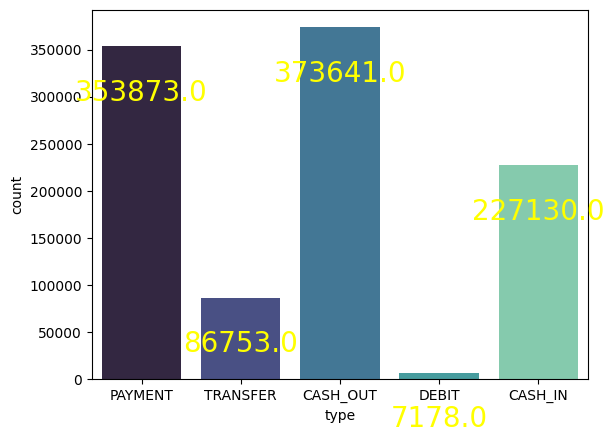

In [12]:
ax=sns.countplot(x='type',data=df,palette="mako")
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}',(p.get_x()+0.4,p.get_height()+100),ha='center',va='top',color='yellow',size=20)
plt.show()

In [13]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import plotly.express as px
px.pie(df,values=quantify,names=transactions,hole=0.4,title="Distribution of transaction type")

In [15]:
from sklearn.preprocessing import LabelEncoder

#Initialize the encoder
le=LabelEncoder()
#Encode categorical columns
df['type'] = le.fit_transform(df['type'])
df['nameOrig'] = le.fit_transform(df['nameOrig'])
df['nameDest'] = le.fit_transform(df['nameDest'])

In [16]:
df.corr()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.015992,-0.025996,-0.000252,-0.006780,-0.007180,0.015275,-0.002251,-0.019503,0.045030,NaN
type,0.015992,1.000000,0.042118,-0.000420,-0.339142,-0.351602,0.586477,-0.166134,-0.127108,0.018859,NaN
amount,-0.025996,0.042118,1.000000,0.001649,0.004864,-0.001133,-0.340864,0.215558,0.311936,0.128862,NaN
nameOrig,-0.000252,-0.000420,0.001649,1.000000,0.000102,0.000143,-0.001146,0.001736,0.001873,0.000030,NaN
oldbalanceOrg,-0.006780,-0.339142,0.004864,0.000102,1.000000,0.999047,-0.160207,0.093305,0.064049,0.003829,NaN
newbalanceOrig,-0.007180,-0.351602,-0.001133,0.000143,0.999047,1.000000,-0.163522,0.095182,0.063725,-0.009438,NaN
nameDest,0.015275,0.586477,-0.340864,-0.001146,-0.160207,-0.163522,1.000000,-0.260621,-0.282134,-0.019759,NaN
oldbalanceDest,-0.002251,-0.166134,0.215558,0.001736,0.093305,0.095182,-0.260621,1.000000,0.978403,-0.007552,NaN
newbalanceDest,-0.019503,-0.127108,0.311936,0.001873,0.064049,0.063725,-0.282134,0.978403,1.000000,-0.000495,NaN
isFraud,0.045030,0.018859,0.128862,0.000030,0.003829,-0.009438,-0.019759,-0.007552,-0.000495,1.000000,NaN


array([[<Axes: title={'center': 'step'}>,
        <Axes: title={'center': 'type'}>,
        <Axes: title={'center': 'amount'}>],
       [<Axes: title={'center': 'nameOrig'}>,
        <Axes: title={'center': 'oldbalanceOrg'}>,
        <Axes: title={'center': 'newbalanceOrig'}>],
       [<Axes: title={'center': 'nameDest'}>,
        <Axes: title={'center': 'oldbalanceDest'}>,
        <Axes: title={'center': 'newbalanceDest'}>],
       [<Axes: title={'center': 'isFraud'}>,
        <Axes: title={'center': 'isFlaggedFraud'}>, <Axes: >]],
      dtype=object)

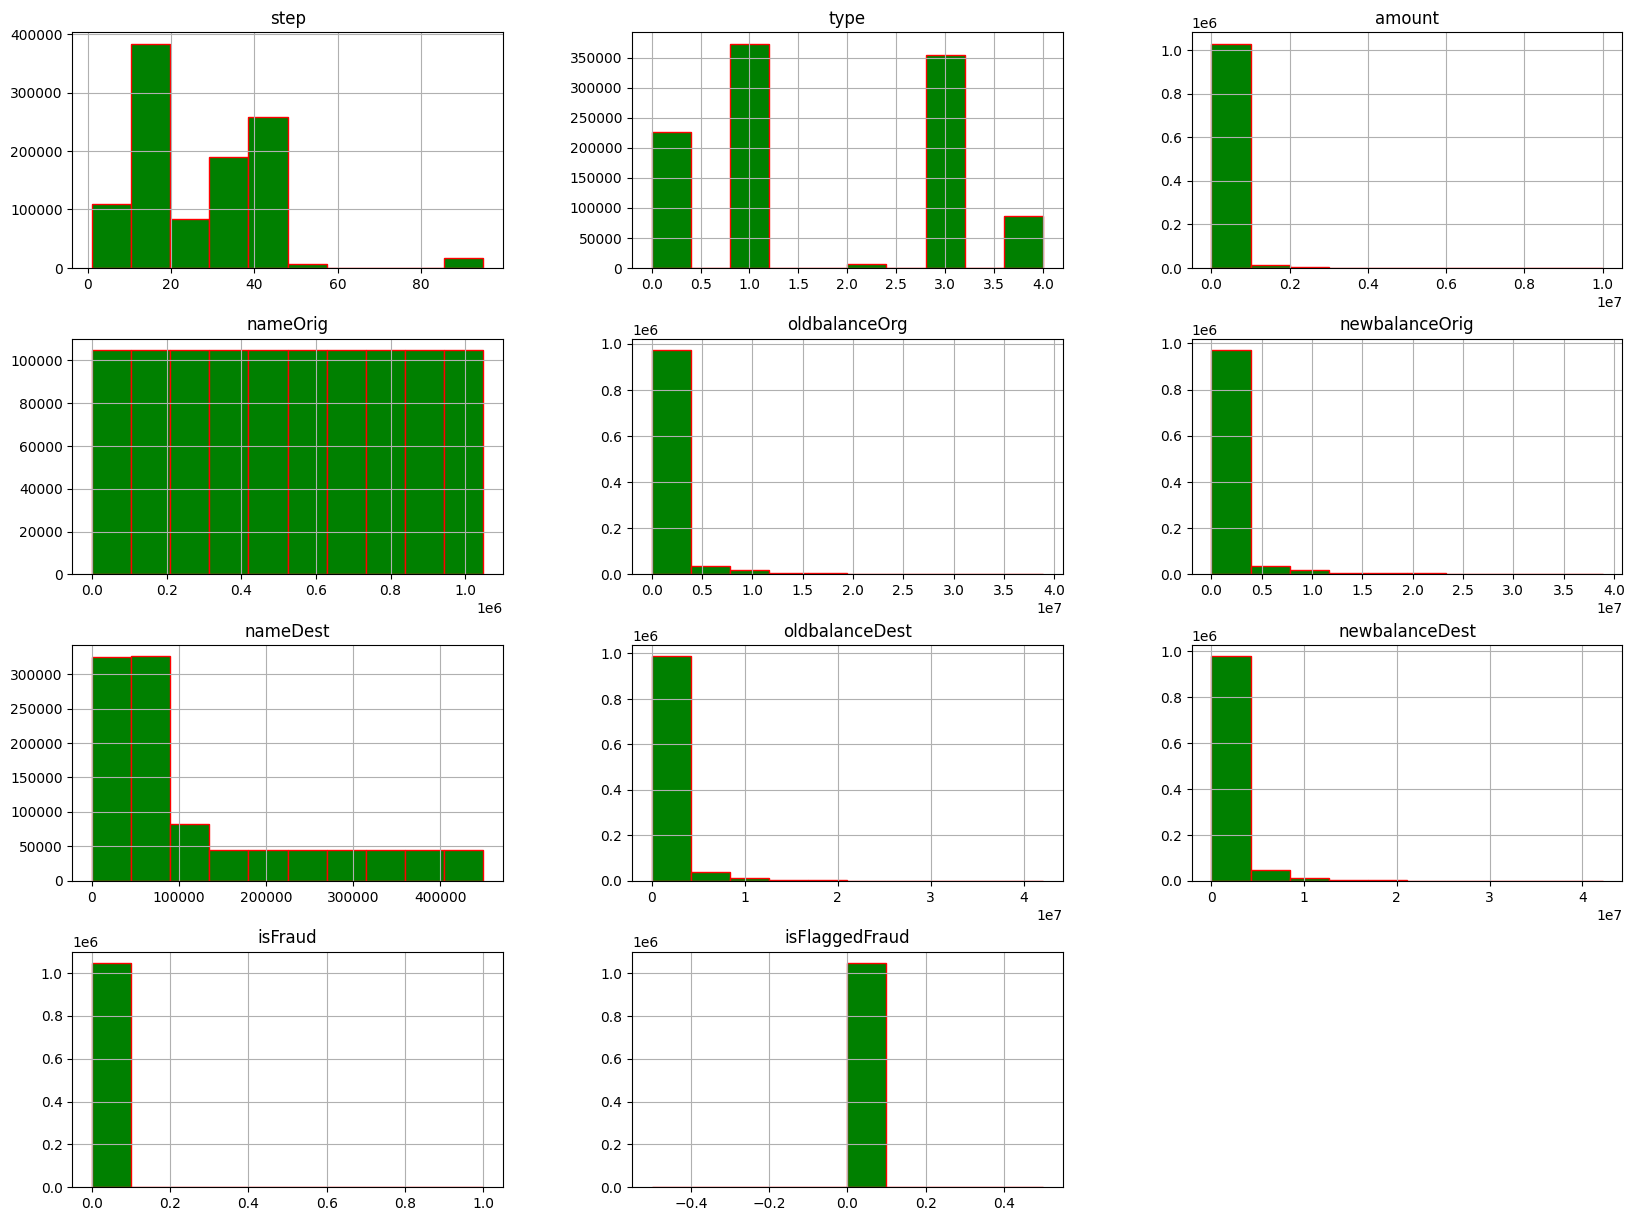

In [17]:
df.hist(figsize=(20,15),color="green",ec="red")  #histograms for all

In [18]:
df=df.dropna()

In [19]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,125164,170136.00,160296.36,274917,0.00,0.00,0,0
1,1,3,1864.28,361319,21249.00,19384.72,286716,0.00,0.00,0,0
2,1,4,181.00,165236,181.00,0.00,73550,0.00,0.00,1,0
3,1,1,181.00,961662,181.00,0.00,65464,21182.00,0.00,1,0
4,1,3,11668.14,567915,41554.00,29885.86,138001,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,1,132557.35,97392,479803.00,347245.65,67716,484329.37,616886.72,0,0
1048571,95,3,9917.36,517554,90545.00,80627.64,388387,0.00,0.00,0,0
1048572,95,3,14140.05,562208,20545.00,6404.95,160789,0.00,0.00,0,0
1048573,95,3,10020.05,343317,90605.00,80584.95,272152,0.00,0.00,0,0


In [20]:
df['isFraud']=df['isFraud'].map({0:'No Fraud',1:'Fraud'})

In [21]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,125164,170136.00,160296.36,274917,0.00,0.00,No Fraud,0
1,1,3,1864.28,361319,21249.00,19384.72,286716,0.00,0.00,No Fraud,0
2,1,4,181.00,165236,181.00,0.00,73550,0.00,0.00,Fraud,0
3,1,1,181.00,961662,181.00,0.00,65464,21182.00,0.00,Fraud,0
4,1,3,11668.14,567915,41554.00,29885.86,138001,0.00,0.00,No Fraud,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,1,132557.35,97392,479803.00,347245.65,67716,484329.37,616886.72,No Fraud,0
1048571,95,3,9917.36,517554,90545.00,80627.64,388387,0.00,0.00,No Fraud,0
1048572,95,3,14140.05,562208,20545.00,6404.95,160789,0.00,0.00,No Fraud,0
1048573,95,3,10020.05,343317,90605.00,80584.95,272152,0.00,0.00,No Fraud,0


In [22]:
df['type'].unique()

array([3, 4, 1, 2, 0])

In [23]:
df.replace(to_replace=['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],value=[2,4,1,3,5], inplace=True)

In [24]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,125164,170136.00,160296.36,274917,0.00,0.00,No Fraud,0
1,1,3,1864.28,361319,21249.00,19384.72,286716,0.00,0.00,No Fraud,0
2,1,4,181.00,165236,181.00,0.00,73550,0.00,0.00,Fraud,0
3,1,1,181.00,961662,181.00,0.00,65464,21182.00,0.00,Fraud,0
4,1,3,11668.14,567915,41554.00,29885.86,138001,0.00,0.00,No Fraud,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,95,1,132557.35,97392,479803.00,347245.65,67716,484329.37,616886.72,No Fraud,0
1048571,95,3,9917.36,517554,90545.00,80627.64,388387,0.00,0.00,No Fraud,0
1048572,95,3,14140.05,562208,20545.00,6404.95,160789,0.00,0.00,No Fraud,0
1048573,95,3,10020.05,343317,90605.00,80584.95,272152,0.00,0.00,No Fraud,0


In [25]:
df['type'].value_counts()

type
1    373641
3    353873
0    227130
4     86753
2      7178
Name: count, dtype: int64

In [26]:
x=df[['type','amount', 'oldbalanceOrg', 'newbalanceOrig']]

In [27]:
y=df.iloc[:,-2]

In [28]:
y

0          No Fraud
1          No Fraud
2             Fraud
3             Fraud
4          No Fraud
             ...   
1048570    No Fraud
1048571    No Fraud
1048572    No Fraud
1048573    No Fraud
1048574    No Fraud
Name: isFraud, Length: 1048575, dtype: object

In [29]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=42)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [31]:
#Create an instance of the LogisticRegression model

logreg = LogisticRegression()
# Fit the model to the training data
logreg.fit(xtrain, ytrain)

c:\Users\91906\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [32]:
y_pred = logreg.predict(xtest)

In [33]:
accuracy = accuracy_score(ytest, y_pred)
print("accuracy:", accuracy)

accuracy: 0.9992752068283146


In [34]:
#model=DecisionTreeClassifier()
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt=DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [36]:
dt_pred=dt.predict(xtest)

In [37]:
dt_accuracy=accuracy_score(ytest,dt_pred)

In [38]:
print("accuracy of decision tree=",dt_accuracy)

accuracy of decision tree= 0.9994134897360704


In [39]:
logreg.predict([[3,98,5567.00,297.36]])

c:\Users\91906\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array(['No Fraud'], dtype=object)

In [40]:
x

,type,amount,oldbalanceOrg,newbalanceOrig
0,3,9839.64,170136.00,160296.36
1,3,1864.28,21249.00,19384.72
2,4,181.00,181.00,0.00
3,1,181.00,181.00,0.00
4,3,11668.14,41554.00,29885.86
...,...,...,...,...
1048570,1,132557.35,479803.00,347245.65
1048571,3,9917.36,90545.00,80627.64
1048572,3,14140.05,20545.00,6404.95
1048573,3,10020.05,90605.00,80584.95


In [41]:
import pickle

In [42]:
filename= 'fraud_detection_model.pk'
pickle.dump(dt,open(filename, 'wb'))

In [43]:
model=pickle.load(open(filename,"rb"))

In [44]:
model.predict([[3,98,5567.00,296.26]])

c:\Users\91906\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



array(['No Fraud'], dtype=object)

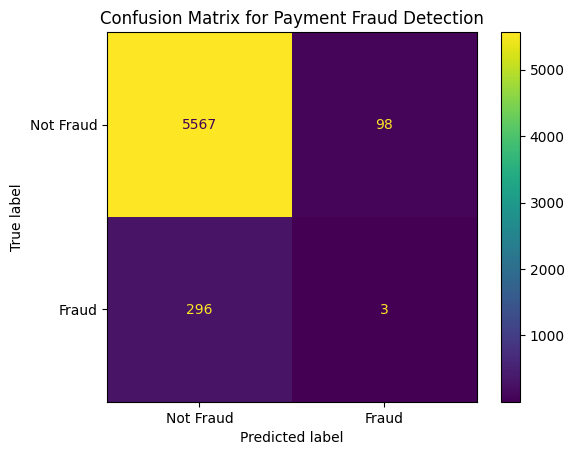

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Input data
tp = 3
fp = 98
tn = 5567
fn = 296

# Construct the confusion matrix
conf_matrix = np.array([[tn, fp], [fn, tp]])

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap='viridis')
plt.title("Confusion Matrix for Payment Fraud Detection")
plt.show()